## Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


## Load and Explore the Data

In [2]:
# load the small transaction data
data = pd.read_csv("../data/raw/HI-Small_Trans.csv")
data.head()

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


In [3]:
# number of rows and columns
data.shape

(5078345, 11)

In [4]:
# column names
print(data.columns.tolist())

['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering']


In [5]:
# data type of each column   
data.dtypes

Timestamp                 str
From Bank               int64
Account                   str
To Bank                 int64
Account.1                 str
Amount Received       float64
Receiving Currency        str
Amount Paid           float64
Payment Currency          str
Payment Format            str
Is Laundering           int64
dtype: object

In [6]:
# null values
data.isnull().sum()

Timestamp             0
From Bank             0
Account               0
To Bank               0
Account.1             0
Amount Received       0
Receiving Currency    0
Amount Paid           0
Payment Currency      0
Payment Format        0
Is Laundering         0
dtype: int64

In [7]:
# how many are laundering vs normal (0: normal, 1: laundering)
data['Is Laundering'].value_counts()

Is Laundering
0    5073168
1       5177
Name: count, dtype: int64

## Visualization

### Amount Distribution

In [8]:
# amount distribution
data['Amount Paid'].describe()

count    5.078345e+06
mean     4.509273e+06
std      8.697728e+08
min      1.000000e-06
25%      1.844800e+02
50%      1.414540e+03
75%      1.229784e+04
max      1.046302e+12
Name: Amount Paid, dtype: float64

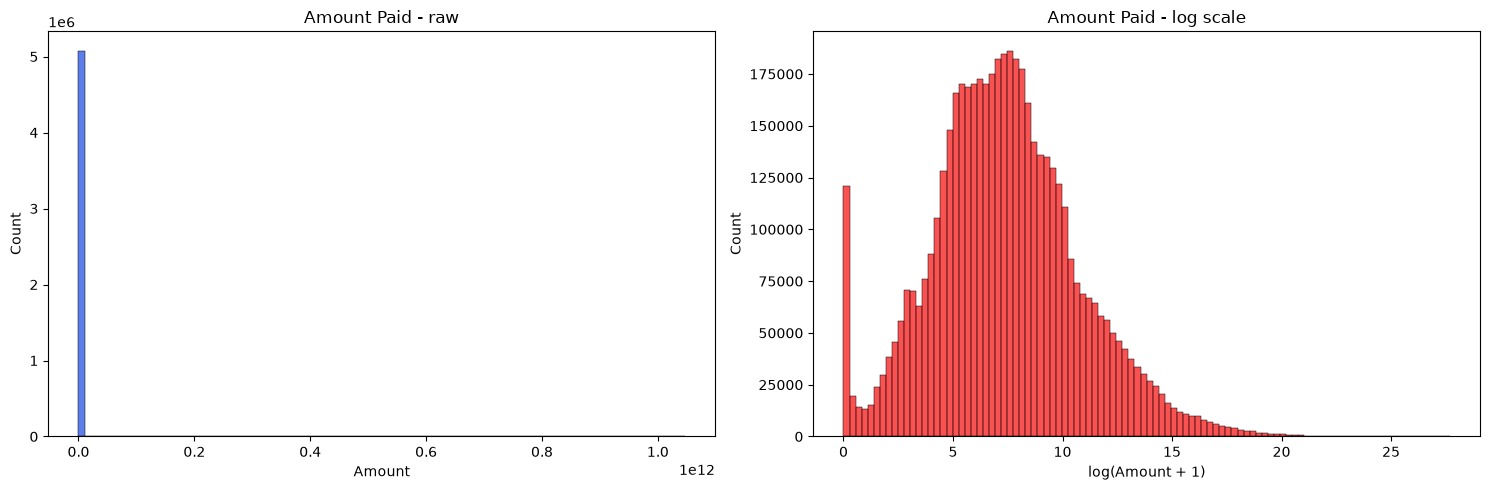

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# raw amounts
sns.histplot(
    data["Amount Paid"], 
    bins=100, color="#1947e1", alpha=0.7, ax=axes[0]
)
axes[0].set_title("Amount Paid - raw")
axes[0].set_xlabel("Amount")

# log scale
sns.histplot(
    np.log1p(data["Amount Paid"]), 
    bins=100, color="#f70808f4", alpha=0.7, ax=axes[1]
)
axes[1].set_title("Amount Paid - log scale")
axes[1].set_xlabel("log(Amount + 1)")

plt.tight_layout()
plt.show()

Money laundering data is usually messy because most transactions are small or normal, but a few are massive.
- The first chart (Raw): Shows the amounts normally. Because huge transactions exist, it squishes everything else into a tiny corner, making it impossible to read.
- The second chart (Log scale): Uses a mathematical function (log) to shrink the giant numbers and stretch out the smaller ones. This helps you actually see the patterns and spread of the data clearly.

### Amounts for Laundering vs Normal

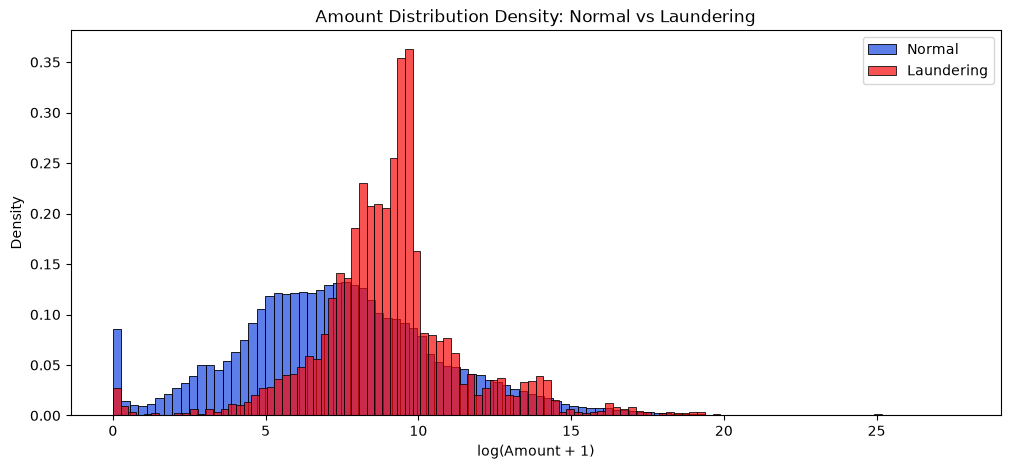

In [10]:
# using stat="density" so both classes scale relative to themselves
fig, ax = plt.subplots(figsize=(12, 5))

# plot normal transactions as a density distribution
sns.histplot(
    np.log1p(data.loc[data["Is Laundering"] == 0, "Amount Paid"]),
    bins=100, color="#1947e1", label="Normal", 
    stat="density", common_norm=False, alpha=0.7, ax=ax
)

# plot laundering transactions as a density distribution
sns.histplot(
    np.log1p(data.loc[data["Is Laundering"] == 1, "Amount Paid"]),
    bins=100, color="#f70808f4", label="Laundering", 
    stat="density", common_norm=False, alpha=0.7, ax=ax
)

ax.set_title("Amount Distribution Density: Normal vs Laundering")
ax.set_xlabel("log(Amount + 1)")
ax.set_ylabel("Density")
ax.legend()
plt.show()

## Currency Mismatch
This is because currency mismatches are a classic AML red flag. Therefore we count how often they happen

In [11]:
print(data["Payment Currency"].value_counts().head(10))

Payment Currency
US Dollar      1895172
Euro           1168297
Swiss Franc     234860
Yuan            213752
Shekel          192184
Rupee           190202
UK Pound        180738
Yen             155209
Ruble           155178
Bitcoin         146066
Name: count, dtype: int64


In [12]:
print(data["Receiving Currency"].value_counts().head(10))

Receiving Currency
US Dollar      1879341
Euro           1172017
Swiss Franc     237884
Yuan            206551
Shekel          194988
Rupee           192065
UK Pound        181255
Ruble           157361
Yen             156319
Bitcoin         148151
Name: count, dtype: int64


In [13]:
print("Currency mismatch (paid ≠ received):")
mismatch = data["Payment Currency"] != data["Receiving Currency"]
print(mismatch.value_counts())

Currency mismatch (paid ≠ received):
False    5006175
True       72170
Name: count, dtype: int64


## Payment formats
Check if some payment formats have much higher fraud rates than others.

In [14]:
print(data["Payment Format"].value_counts())

Payment Format
Cheque          1864331
Credit Card     1323324
ACH              600797
Cash             490891
Reinvestment     481056
Wire             171855
Bitcoin          146091
Name: count, dtype: int64


In [15]:
fraud_rate_by_format = data.groupby("Payment Format")["Is Laundering"].mean() * 100
print("Laundering rate by payment format in (%) :\n", fraud_rate_by_format.sort_values(ascending=False))

Laundering rate by payment format in (%) :
 Payment Format
ACH             0.746175
Bitcoin         0.038332
Cash            0.022001
Cheque          0.017379
Credit Card     0.015567
Reinvestment    0.000000
Wire            0.000000
Name: Is Laundering, dtype: float64


## Banks
- Are there a few dominant banks, or is it spread out? 
- Are certain bank pairs suspicious?

In [16]:
print("From Bank (top 10):")
print(data["From Bank"].value_counts().head(10))

From Bank (top 10):
From Bank
70     449859
10      81629
12      79754
1       62211
15      52511
220     52417
20      41008
3       38413
7       31086
211     30451
Name: count, dtype: int64


In [17]:
print("To Bank (top 10):")
print(data["To Bank"].value_counts().head(10))

To Bank (top 10):
To Bank
10     42547
12     41872
15     38721
220    30625
1      30115
3      25627
7      23029
20     22048
28     21160
211    20576
Name: count, dtype: int64


## Time patterns
Do laundering transactions happen more at night? On weekends?

In [18]:
data["Timestamp"] = pd.to_datetime(data["Timestamp"])
data["hour"] = data["Timestamp"].dt.hour
data["day_of_week"] = data["Timestamp"].dt.day_name()

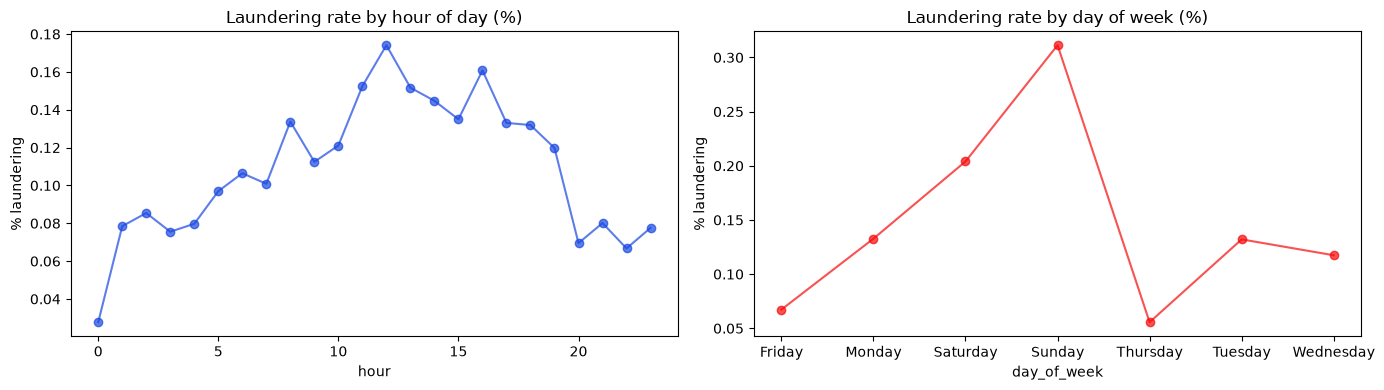

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

data.groupby("hour")["Is Laundering"].mean().mul(100).plot(ax=axes[0], marker="o", color="#1947e1", alpha=0.7)
axes[0].set_title("Laundering rate by hour of day (%)")
axes[0].set_ylabel("% laundering")

data.groupby("day_of_week")["Is Laundering"].mean().mul(100).plot(ax=axes[1], marker="o", color="#f70808f4", alpha=0.7)
axes[1].set_title("Laundering rate by day of week (%)")
axes[1].set_ylabel("% laundering")

plt.tight_layout()
plt.show()

## Account activity
Check if any account sends hundreds of transactions

In [20]:
sender_counts = data["Account"].value_counts()
receiver_counts = data["Account.1"].value_counts()

In [21]:
print("Top 10 most active senders:")
print(sender_counts.head(10))

Top 10 most active senders:
Account
100428660    168672
1004286A8    103018
100428978     20497
1004286F0     18663
100428780     17264
1004289C0     16794
100428810     16426
1004287C8     14174
100428738     13756
100428A51     13073
Name: count, dtype: int64


In [22]:
print("Sender activity stats:")
print(sender_counts.describe())

Sender activity stats:
count    496995.000000
mean         10.218101
std         290.284113
min           1.000000
25%           1.000000
50%           2.000000
75%           5.000000
max      168672.000000
Name: count, dtype: float64


In [23]:
print("Top 10 most active receivers:")
print(receiver_counts.head(10))

Top 10 most active receivers:
Account.1
100428660    1084
1004286A8     653
80F47A310     159
100428978     150
8018859B0     144
1004289C0     132
100428780     117
100428810     114
80F0EF460     109
1004286F0     108
Name: count, dtype: int64


## Are laundering accounts repeat offenders?
If one account appears 50 times in laundering, that's a mule account. This is the pattern the rules should catch.

In [24]:
fraud_accounts = data.loc[data["Is Laundering"] == 1, "Account"].value_counts()

In [25]:
print("Accounts involved in laundering (top 10):")
print(fraud_accounts.head(10))

Accounts involved in laundering (top 10):
Account
100428660    243
1004286A8    158
100428978     29
80266F880     29
100428810     26
812D22980     25
100428738     23
811C597B0     21
811C599A0     21
100428780     21
Name: count, dtype: int64


In [26]:
print(f"Unique laundering senders: {fraud_accounts.shape[0]}")

Unique laundering senders: 3376


In [27]:
print(f"Max laundering txns from one account: {fraud_accounts.max()}")

Max laundering txns from one account: 243


## Finding 5: Repeat offenders exist and are extreme.
- The top account (100428660) sent 243 laundering transactions. The next has 158. There are 3,376 unique laundering senders, i.e 5,177 laundering transactions spread across 3,376 accounts means most laundering accounts send 1–2 transactions, but a small handful send hundreds. This is a mule account pattern.
- Rule to add: any account with more than 20 outgoing transactions in a 30-day window, we auto-flag. This will help catch the top offenders with almost zero false positives.

## Save the cleaned data
Parquet because it is faster and smaller than CSV

In [28]:
import os
os.makedirs("../data/processed", exist_ok=True)

data.to_parquet("../data/processed/transactions_clean.parquet", index=False)
print("Saved.")

Saved.


## Key findings
1. Class imbalance: 0.10% laundering (5,177 / 5,078,345). This means the baseline accuracy is about 99.9% but not useful.
2. Laundering amounts cluster around $13k–$22k - structuring behavior.
3. Micro-transactions (~$0.01) are over-represented - test transactions.
4. ACH payment format has 20× the fraud rate of Cheque.
5. Laundering is highest at noon and on Sundays - hidden in normal traffic.
6. Currency mismatch happens in 1.4% of transactions.
7. 3,376 unique laundering senders, but top account sent 243 - mule pattern.